# 06f · GSE65391 · RNA_array · patient-group profiles with our methods: Ward trees and k-means

Reads `pg_profiles.rds` (notebook 06d) and `pg_paper_groups.csv` (notebook 06e).

**Two profiles, side by side** (notebook 06d), one row per child:
- `net5`: SLEDAI correlation with the paper's five networks (797 probes);
- `mod16`: SLEDAI correlation with our 14 array modules.

**Methods, as in notebooks 07 and 08.**
- Ward's method (`ward.D2`; Ward JH. *J Am Stat Assoc* 1963;58:236-244; Murtagh F, Legendre P. *J Classif*
  2014;31:274-295) on Minkowski distance with p = 2, children and features. The trees are drawn whole.
- k-means on the children for K = 2 to 8, each scored with the mean silhouette width (Rousseeuw PJ.
  *J Comput Appl Math* 1987;20:53-65; reading guide in notebook 08).

The seven groups rebuilt in notebook 06e are shown as a strip, for reading only.

## Load the profiles

In [1]:
source("../src/paths.R")
suppressMessages({library(cluster); library(ComplexHeatmap); library(circlize)})
pg <- readRDS(art("GSE65391", "pg_profiles.rds"))
paper7 <- read.csv(art("GSE65391", "pg_paper_groups.csv"))
g7 <- factor(paper7$group[match(rownames(pg$net5), paper7$subject)])
profiles <- list(net5 = pg$net5, mod16 = pg$mod16)
sapply(profiles, dim)

net5,mod16
83,83
5,14


**Explanation**
- `library(ComplexHeatmap)` draws heatmaps with dendrograms and annotation strips (Gu Z, Eils R, Schlesner M.
  Complex heatmaps reveal patterns and correlations in multidimensional genomic data. *Bioinformatics*
  2016;32:2847-2849). `library(circlize)` provides `colorRamp2()`, which maps numbers to colours (Gu Z, Gu L,
  Eils R, Schlesner M, Brors B. circlize implements and enhances circular visualization in R. *Bioinformatics*
  2014;30:2811-2812).
- `pg_profiles.rds` from notebook 06d; `pg_paper_groups.csv` from notebook 06e.
- `g7` holds each child's 06e group in the row order of the profiles.
- `profiles` is a list of the two profiles; `sapply(profiles, dim)` prints their sizes.

## k-means and mean silhouette on each profile

In [2]:
sil <- lapply(profiles, function(P) {
  d <- dist(P)
  do.call(rbind, lapply(2:8, function(k) {
    set.seed(SEED); km <- kmeans(P, k, nstart = 50, iter.max = 100)
    data.frame(k = k, mean_silhouette = round(mean(silhouette(km$cluster, d)[, "sil_width"]), 3),
               cluster_sizes = paste(sort(table(km$cluster), decreasing = TRUE), collapse = " "))
  }))
})
sil

k,mean_silhouette,cluster_sizes
<int>,<dbl>,<chr>
2,0.313,43 40
3,0.243,34 33 16
4,0.277,38 16 15 14
5,0.265,22 16 16 15 14
6,0.271,21 16 15 15 14 2
7,0.275,20 20 12 12 10 7 2
8,0.277,18 18 12 11 10 7 5 2
k,mean_silhouette,cluster_sizes
<int>,<dbl>,<chr>


**Explanation**
- For each profile and each K from 2 to 8: k-means with 50 random starts, then the mean silhouette width and
  the cluster sizes, as in notebook 08.

**Result.**
- **Five networks.** The highest mean silhouette is at K = 2 (0.313: 43 and 40 children); K = 3 to 8 give 0.243
  to 0.277. K = 2 is in the reading guide's weak-structure range (0.26 to 0.50); K = 7, the paper's number,
  gives 0.275.
- **14 modules.** The mean silhouette is 0.100 to 0.155, highest at K = 2 (44 and 39 children).

## Ward heatmaps of the two profiles

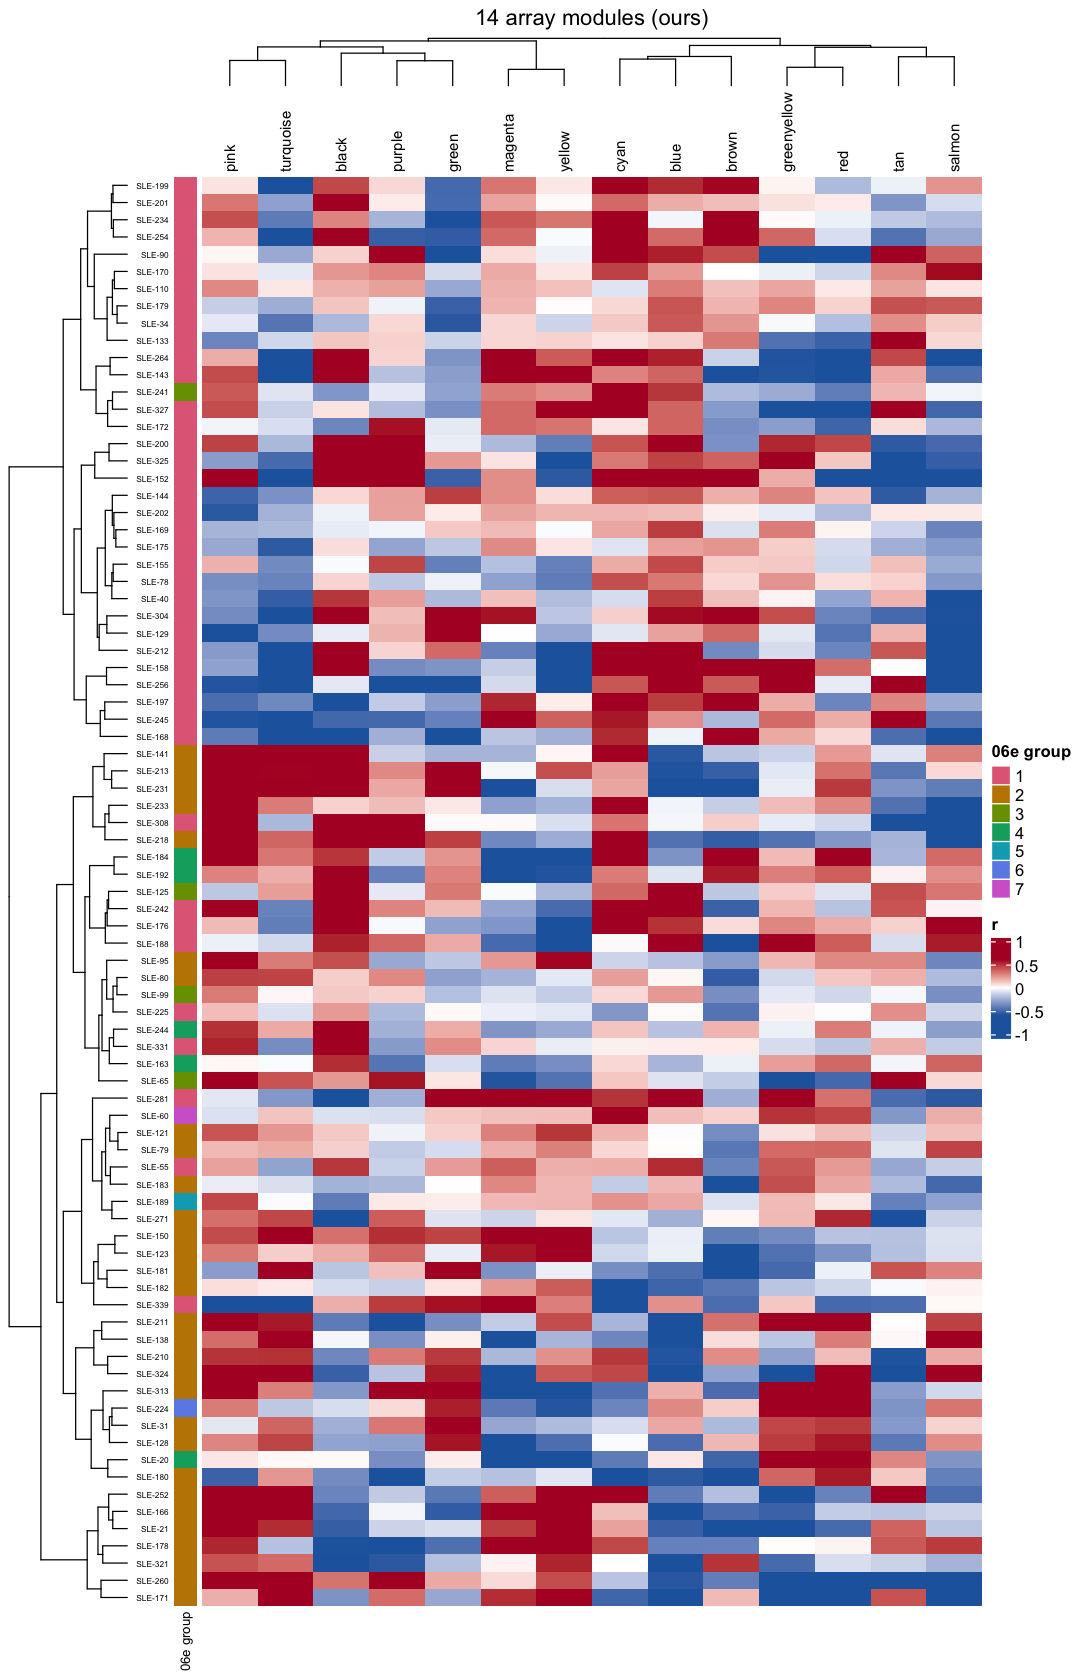

In [3]:
heat <- function(P, title, cols) {
  Heatmap(P, name = "r", col = colorRamp2(c(-0.6, 0, 0.6), c("#2166AC", "white", "#B2182B")),
          clustering_distance_rows = function(m) dist(m, method = "minkowski", p = 2), clustering_method_rows = "ward.D2",
          clustering_distance_columns = function(m) dist(m, method = "minkowski", p = 2), clustering_method_columns = "ward.D2",
          cluster_columns = cols,
          row_dend_side = "left", column_dend_side = "top", row_dend_width = unit(25, "mm"),
          show_row_names = TRUE, row_names_side = "left", row_names_gp = gpar(fontsize = 5),
          column_names_side = "top", column_names_gp = gpar(fontsize = 9),
          left_annotation = rowAnnotation(`06e group` = g7, col = list(`06e group` = setNames(hcl.colors(7, "Dark 3"), levels(g7))),
                                          annotation_name_gp = gpar(fontsize = 8)),
          column_title = title)
}
options(repr.plot.width = 9, repr.plot.height = 14)
for (nm in names(profiles)) {                        # one figure per profile, each with its own Ward trees
  figure <- function() heat(profiles[[nm]], c(net5 = "five networks (paper's 797 probes)", mod16 = "14 array modules (ours)")[[nm]], TRUE)
  for (device in c("inline", "png")) {             # shown here, and saved as a 300 dpi PNG
    if (device == "png") png(fig("GSE65391", paste0("06f_PG_ward_", nm, ".png")), width = 9, height = 14, units = "in", res = 300)
    out <- figure(); if (inherits(out, c("Heatmap", "HeatmapList"))) draw(out)
    if (device == "png") invisible(dev.off())
  }
}

**Explanation**
- `heat(P, title, cols)` draws one heatmap of a profile:
  - `clustering_distance_rows = function(m) dist(m, method = "minkowski", p = 2)` and
    `clustering_method_rows = "ward.D2"` cluster the children with Ward's method on Euclidean distance (see
    notebook 07); the same for the columns.
  - Children's tree and identifiers on the left, feature names on top.
  - The strip on the left marks the 06e groups.
- The loop draws one figure per profile, each with its own trees, and saves each as a PNG.
- `c(net5 = "...", mod16 = "...")[[nm]]` picks the title that matches the profile's name.
- The figure loop is explained in notebook 04.

**Reading the figures.** The Ward trees are drawn whole; the strip marks the groups of notebook 06e, for
reading only.
- In the five-network figure, the two large 06e groups sit at opposite ends of the tree: group 2, where the
  plasma-cell and lymphoid networks rise with SLEDAI, at the top; group 1, where interferon and myeloid rise,
  at the bottom. The small groups lie between them.
- In the 14-module figure the same two groups are mostly at the two ends, with more mixing in the middle.